In [1]:
2+2

4

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from Tracer import WindField, Trajectory

# xy grid test 
filexy1m = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\RANS\nc files\flowdata_xy1m_mb_cartesian.nc'
filexy2m = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_xy2m_mb_cartesian.nc'
filexy4m = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_xy4m_mb_cartesian.nc'
filexy8m = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_xy8m_mb_cartesian.nc'
filexy16m = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_xy16m_mb_cartesian.nc'

# z grid test
filez1m = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_z0025m_1m_cartesian.nc'
filez2m = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_z005m_2m_cartesian.nc'
filez4m = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_z01m_4m_cartesian.nc'
filez8m = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_z02m_8m_mb_cartesian.nc'
filez16m = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_z04m_16m_mb_cartesian.nc'

files = {
    'xy=1m': filexy1m,
    'xy=2m': filexy2m,
    'xy=4m': filexy4m,
    'xy=8m': filexy8m,
    'xy=16m': filexy16m,
    'z=0.025m_1m' : filez1m,
    'z=0.05m_2m' : filez2m,
    'z=0.1m_4m' : filez4m,
    'z=0.2m_8m' : filez8m,
    'z=0.4m_16m' : filez16m
}

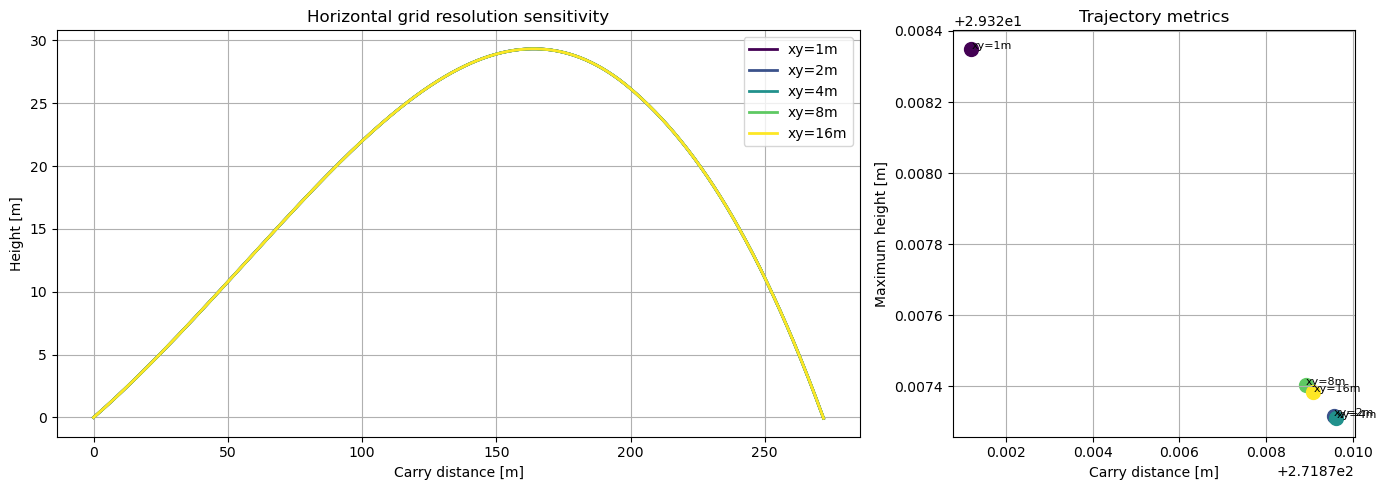

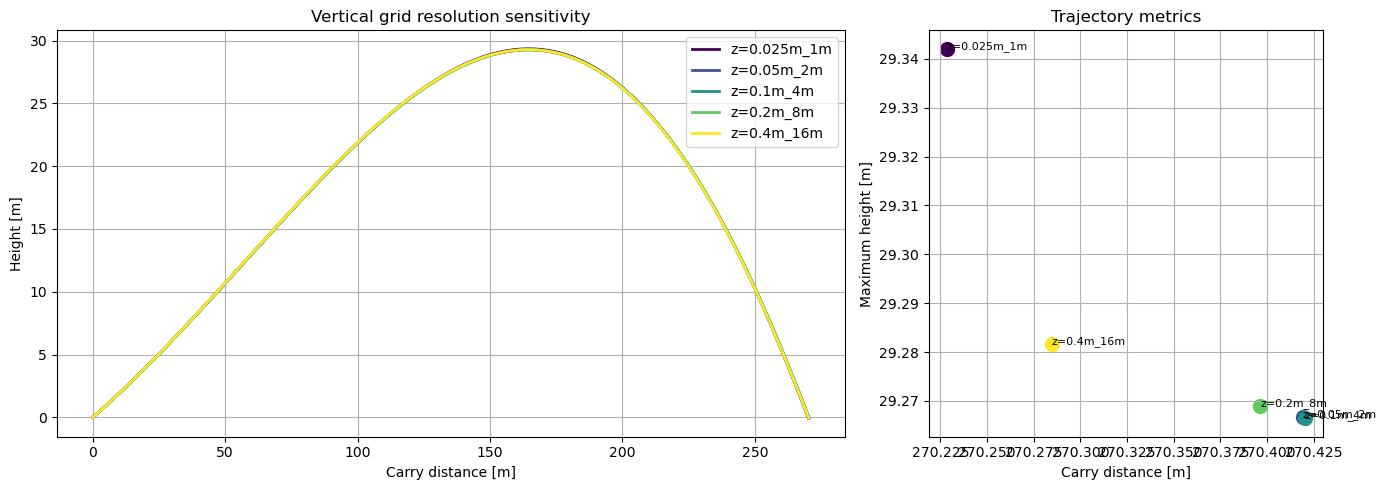


GRID FIDELITY ERRORS

Horizontal grid sensitivity


,Case,Abs Error [m],Percent Error [%],dx Error [m],dy Error [m],Carry [m],Max Height [m]
0,xy=2m,0.008370,0.003079,0.008370,-0.000012,271.879566,29.327317
1,xy=4m,0.008425,0.003099,0.008425,0.000005,271.879621,29.327311
2,xy=8m,0.007715,0.002838,0.007715,0.000007,271.878912,29.327405
3,xy=16m,0.007897,0.002905,0.007897,0.000004,271.879093,29.327383



Vertical grid sensitivity


,Case,Abs Error [m],Percent Error [%],dx Error [m],dy Error [m],Carry [m],Max Height [m]
0,z=0.05m_2m,0.190543,0.070512,0.190543,0.000023,270.418985,29.266721
1,z=0.1m_4m,0.191819,0.070984,0.191819,0.000036,270.420260,29.266443
2,z=0.2m_8m,0.168015,0.062175,0.168015,0.000024,270.396457,29.268904
3,z=0.4m_16m,0.056071,0.020749,0.056071,0.000018,270.284512,29.281696


In [7]:
# ============================================================
# Error models
# ============================================================

def percent_distance_error(ref_p, test_p):
    dx = test_p[-1, 0] - ref_p[-1, 0]
    dy = test_p[-1, 1] - ref_p[-1, 1]

    norm = np.sqrt(
        (ref_p[-1, 0] - ref_p[0, 0])**2 +
        (ref_p[-1, 1] - ref_p[0, 1])**2
    )

    return np.sqrt(dx**2 + dy**2) / norm * 100


def distance_error(ref_p, test_p):
    dx = test_p[-1, 0] - ref_p[-1, 0]
    dy = test_p[-1, 1] - ref_p[-1, 1]

    return np.sqrt(dx**2 + dy**2)


def x_distance_error(ref_p, test_p):
    return test_p[-1, 0] - ref_p[-1, 0]


def y_distance_error(ref_p, test_p):
    return test_p[-1, 1] - ref_p[-1, 1]


# ============================================================
# Trajectory metrics
# ============================================================

def carry_distance(p):
    return p[-1, 0] - p[0, 0]


def max_height(p):
    return np.max(p[:, 2])


# ============================================================
# Solve trajectories
# ============================================================

trajectories = {}

for key, file in files.items():

    wind = WindField(profile='rans', ds=file)

    traj = Trajectory(
        ball_speed=76.44384,
        launch_angle=10.4,
        spin_rate=2545,
        spin_axis=0,
        wind=wind
    )

    traj.solve(solver='euler', dt=0.01)

    trajectories[key] = traj


# ============================================================
# XY GRID COMPARISON
# ============================================================

xy_keys = ['xy=1m', 'xy=2m', 'xy=4m', 'xy=8m', 'xy=16m']

fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(14, 5),
    gridspec_kw={'width_ratios': [2, 1]}
)

colors = plt.cm.viridis(np.linspace(0, 1, len(xy_keys)))

# ------------------------------------------------------------
# Left: trajectories
# ------------------------------------------------------------

for i, key in enumerate(xy_keys):

    p = trajectories[key].p

    ax1.plot(
        p[:, 0],
        p[:, 2],
        linewidth=2,
        color=colors[i],
        label=key
    )

ax1.set_xlabel('Carry distance [m]')
ax1.set_ylabel('Height [m]')
ax1.set_title('Horizontal grid resolution sensitivity')
ax1.grid(True)
ax1.legend()

# ------------------------------------------------------------
# Right: carry vs apex
# ------------------------------------------------------------

for i, key in enumerate(xy_keys):

    p = trajectories[key].p

    carry = carry_distance(p)
    apex = max_height(p)

    ax2.scatter(
        carry,
        apex,
        s=100,
        color=colors[i],
        label=key
    )

    ax2.text(
        carry,
        apex,
        key,
        fontsize=8
    )

ax2.set_xlabel('Carry distance [m]')
ax2.set_ylabel('Maximum height [m]')
ax2.set_title('Trajectory metrics')
ax2.grid(True)

plt.tight_layout()
plt.show()


z_keys = [
    'z=0.025m_1m',
    'z=0.05m_2m',
    'z=0.1m_4m',
    'z=0.2m_8m',
    'z=0.4m_16m'
]

fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(14, 5),
    gridspec_kw={'width_ratios': [2, 1]}
)

colors = plt.cm.viridis(np.linspace(0, 1, len(z_keys)))

# ------------------------------------------------------------
# Left: trajectories
# ------------------------------------------------------------

for i, key in enumerate(z_keys):

    p = trajectories[key].p

    ax1.plot(
        p[:, 0],
        p[:, 2],
        linewidth=2,
        color=colors[i],
        label=key
    )

ax1.set_xlabel('Carry distance [m]')
ax1.set_ylabel('Height [m]')
ax1.set_title('Vertical grid resolution sensitivity')
ax1.grid(True)
ax1.legend()

# ------------------------------------------------------------
# Right: carry vs apex
# ------------------------------------------------------------

for i, key in enumerate(z_keys):

    p = trajectories[key].p

    carry = carry_distance(p)
    apex = max_height(p)

    ax2.scatter(
        carry,
        apex,
        s=100,
        color=colors[i]
    )

    ax2.text(
        carry,
        apex,
        key,
        fontsize=8
    )

ax2.set_xlabel('Carry distance [m]')
ax2.set_ylabel('Maximum height [m]')
ax2.set_title('Trajectory metrics')
ax2.grid(True)

plt.tight_layout()
plt.show()

print('\n============================================================')
print('GRID FIDELITY ERRORS')
print('============================================================')

ref_xy = trajectories['xy=1m'].p
xy_rows = []
for key in ['xy=2m', 'xy=4m', 'xy=8m', 'xy=16m']:

    test_p = trajectories[key].p

    xy_rows.append({
        'Case': key,
        'Abs Error [m]':
            distance_error(ref_xy, test_p),

        'Percent Error [%]':
            percent_distance_error(ref_xy, test_p),

        'dx Error [m]':
            x_distance_error(ref_xy, test_p),

        'dy Error [m]':
            y_distance_error(ref_xy, test_p),

        'Carry [m]':
            carry_distance(test_p),

        'Max Height [m]':
            max_height(test_p)
    })

xy_df = pd.DataFrame(xy_rows)

print('\nHorizontal grid sensitivity')
display(xy_df.round(6))

ref_z = trajectories['z=0.025m_1m'].p
z_rows = []
for key in [
    'z=0.05m_2m',
    'z=0.1m_4m',
    'z=0.2m_8m',
    'z=0.4m_16m'
]:

    test_p = trajectories[key].p

    z_rows.append({
        'Case': key,
        'Abs Error [m]':
            distance_error(ref_z, test_p),

        'Percent Error [%]':
            percent_distance_error(ref_z, test_p),

        'dx Error [m]':
            x_distance_error(ref_z, test_p),

        'dy Error [m]':
            y_distance_error(ref_z, test_p),

        'Carry [m]':
            carry_distance(test_p),

        'Max Height [m]':
            max_height(test_p)
    })

z_df = pd.DataFrame(z_rows)

print('\nVertical grid sensitivity')
display(z_df.round(6))

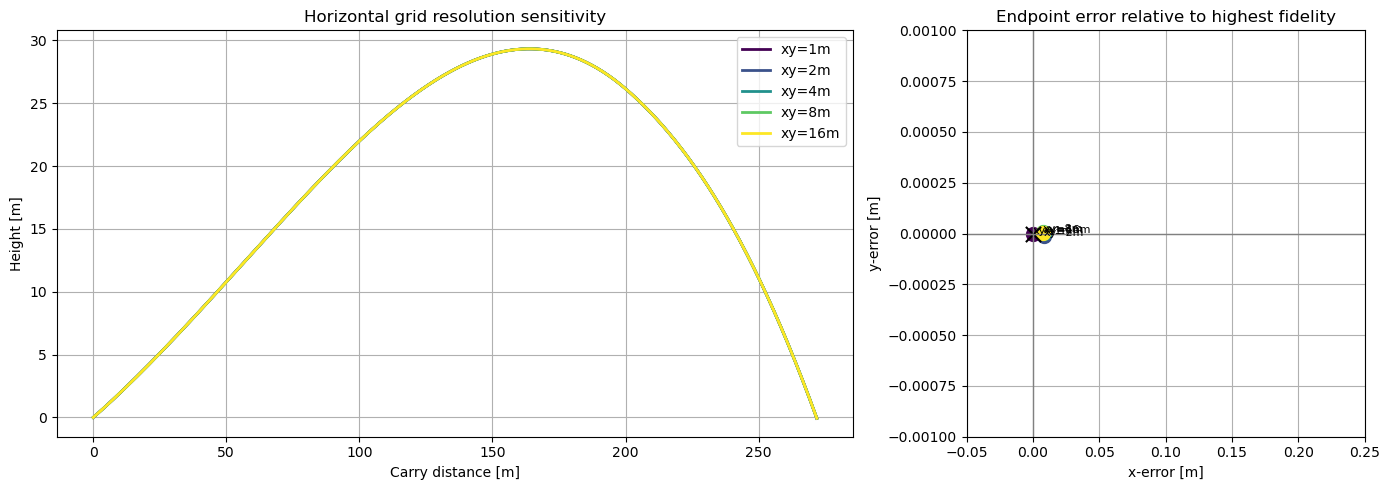

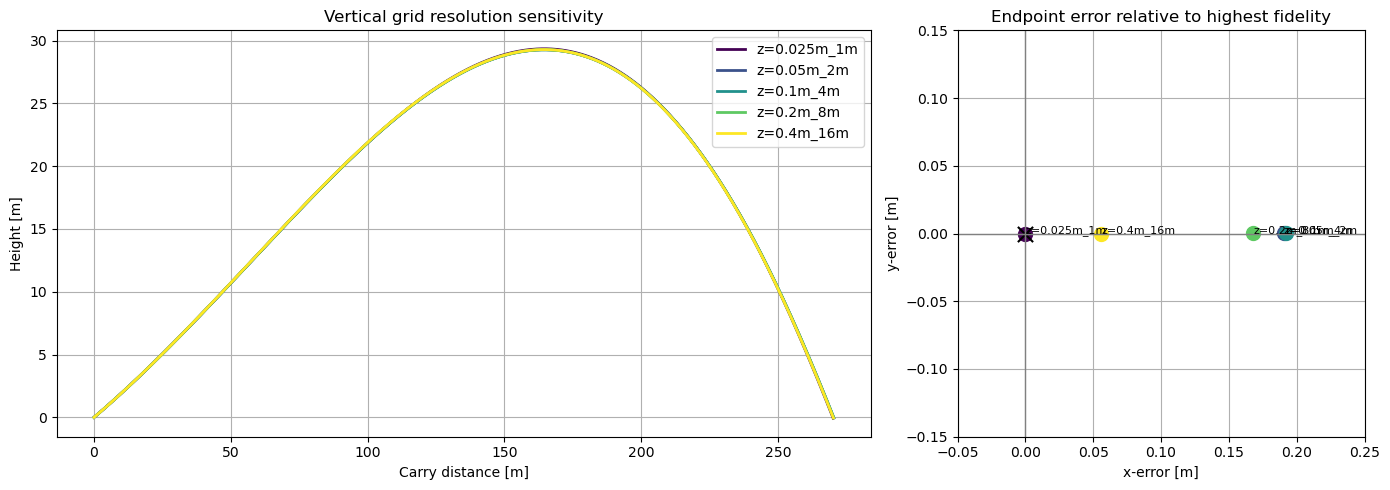

In [30]:
# ============================================================
# Solve trajectories
# ============================================================

trajectories = {}

for key, file in files.items():

    wind = WindField(profile='rans', ds=file)

    traj = Trajectory(
        ball_speed=76.44384,
        launch_angle=10.4,
        spin_rate=2545,
        spin_axis=0,
        wind=wind
    )

    traj.solve(solver='euler', dt=0.01)

    trajectories[key] = traj


# ============================================================
# XY GRID COMPARISON
# ============================================================

xy_keys = ['xy=1m', 'xy=2m', 'xy=4m', 'xy=8m', 'xy=16m']

fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(14, 5),
    gridspec_kw={'width_ratios': [2, 1]}
)

colors = plt.cm.viridis(np.linspace(0, 1, len(xy_keys)))

# ------------------------------------------------------------
# Left: trajectories
# ------------------------------------------------------------

for i, key in enumerate(xy_keys):

    p = trajectories[key].p

    ax1.plot(
        p[:, 0],
        p[:, 2],
        linewidth=2,
        color=colors[i],
        label=key
    )

ax1.set_xlabel('Carry distance [m]')
ax1.set_ylabel('Height [m]')
ax1.set_title('Horizontal grid resolution sensitivity')
ax1.grid(True)
ax1.legend()

# ------------------------------------------------------------
# Right: x-error vs y-error
# ------------------------------------------------------------

ref_xy = trajectories['xy=1m'].p

for i, key in enumerate(xy_keys):

    p = trajectories[key].p

    dx = x_distance_error(ref_xy, p)
    dy = y_distance_error(ref_xy, p)

    ax2.scatter(
        dx,
        dy,
        s=100,
        color=colors[i],
        label=key
    )

    ax2.text(
        dx,
        dy,
        key,
        fontsize=8
    )

# reference marker at origin
ax2.scatter(
    0,
    0,
    color='black',
    marker='x',
    s=120,
    label='Reference'
)

ax2.set_xlabel('x-error [m]')
ax2.set_ylabel('y-error [m]')
ax2.set_xlim(-0.05,0.25)
ax2.set_ylim(-0.15,0.15)
ax2.set_title('Endpoint error relative to highest fidelity')
ax2.grid(True)
ax2.axhline(0, color='gray', linewidth=1)
ax2.axvline(0, color='gray', linewidth=1)

plt.tight_layout()
plt.show()


z_keys = [
    'z=0.025m_1m',
    'z=0.05m_2m',
    'z=0.1m_4m',
    'z=0.2m_8m',
    'z=0.4m_16m'
]

fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(14, 5),
    gridspec_kw={'width_ratios': [2, 1]}
)

colors = plt.cm.viridis(np.linspace(0, 1, len(z_keys)))

# ------------------------------------------------------------
# Left: trajectories
# ------------------------------------------------------------

for i, key in enumerate(z_keys):

    p = trajectories[key].p

    ax1.plot(
        p[:, 0],
        p[:, 2],
        linewidth=2,
        color=colors[i],
        label=key
    )

ax1.set_xlabel('Carry distance [m]')
ax1.set_ylabel('Height [m]')
ax1.set_title('Vertical grid resolution sensitivity')
ax1.grid(True)
ax1.legend()

# ------------------------------------------------------------
# Right: x-error vs y-error
# ------------------------------------------------------------

ref_z = trajectories['z=0.025m_1m'].p

for i, key in enumerate(z_keys):

    p = trajectories[key].p

    dx = x_distance_error(ref_z, p)
    dy = y_distance_error(ref_z, p)

    ax2.scatter(
        dx,
        dy,
        s=100,
        color=colors[i]
    )

    ax2.text(
        dx,
        dy,
        key,
        fontsize=8
    )

# reference marker at origin
ax2.scatter(
    0,
    0,
    color='black',
    marker='x',
    s=120,
    label='Reference'
)

ax2.set_xlabel('x-error [m]')
ax2.set_ylabel('y-error [m]')
ax2.set_xlim(-0.05,0.25)
ax2.set_ylim(-0.15,0.15)
ax2.set_title('Endpoint error relative to highest fidelity')
ax2.grid(True)
ax2.axhline(0, color='gray', linewidth=1)
ax2.axvline(0, color='gray', linewidth=1)

plt.tight_layout()
plt.show()

## Looking closer at vertical wind profiles

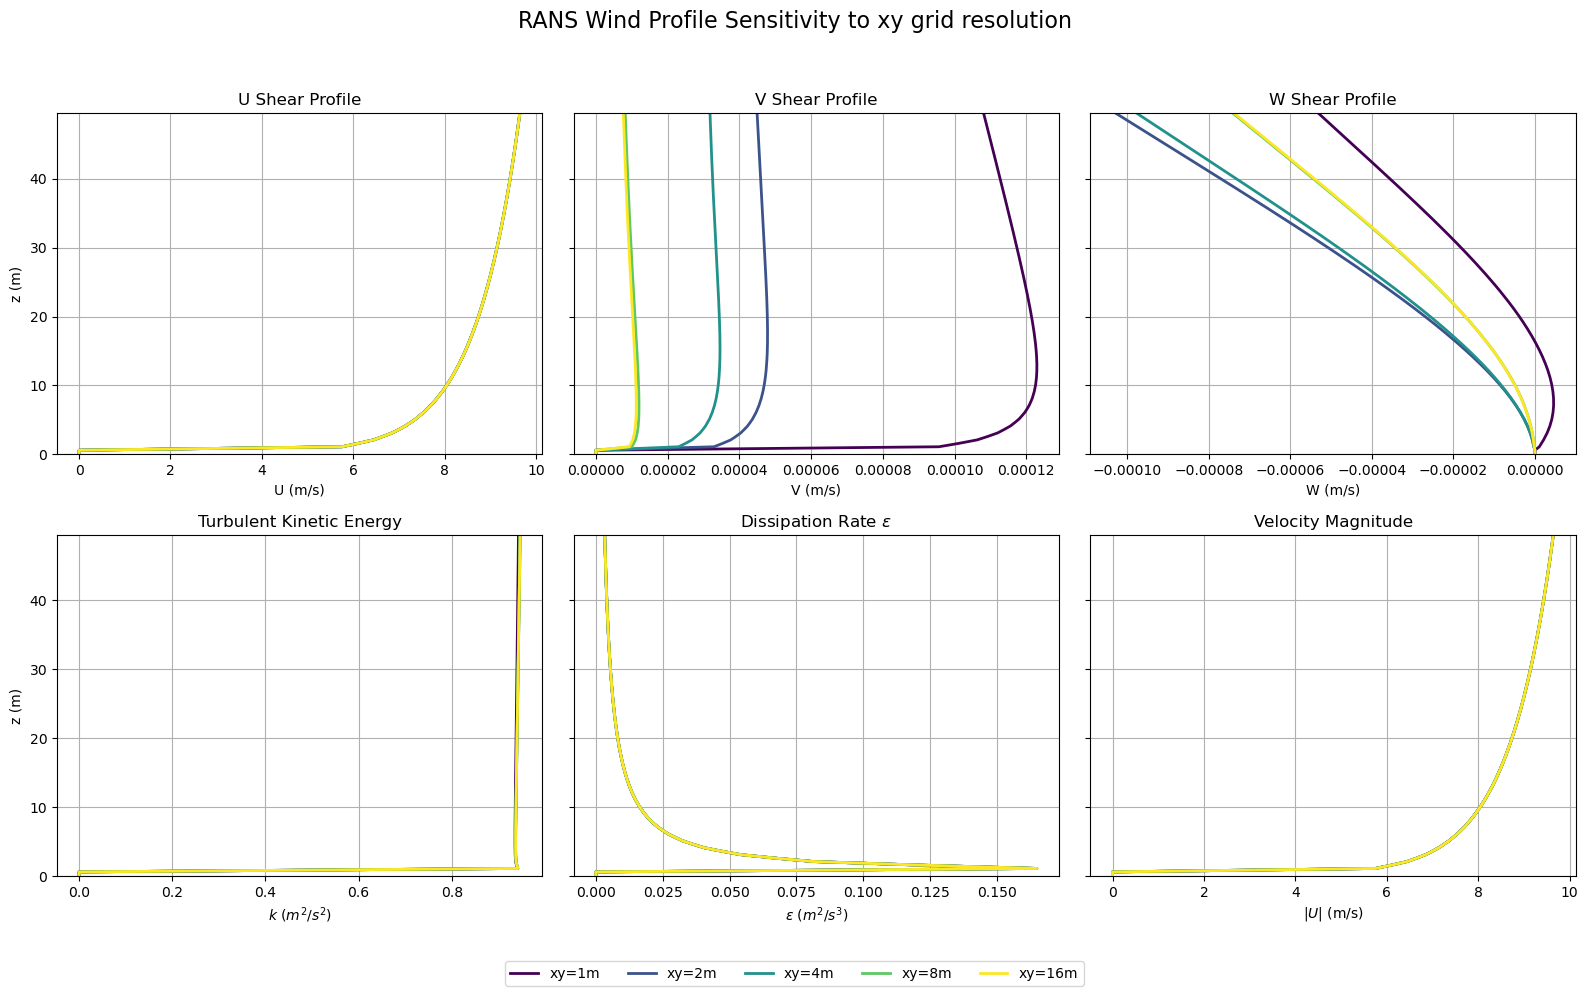

In [10]:
ylowlim = 0
yhighlim = 49.5

# RANS WIND PROFILE COMPARISON 
z_names_prop = ['z=0.025m_1m','z=0.05m_2m','z=0.1m_4m','z=0.2m_8m','z=0.4m_16m']
xy_names_prop = ['xy=1m','xy=2m','xy=4m','xy=8m','xy=16m']
case_names = xy_names_prop
wfs = {}

for name in case_names:
    wfs[name] = WindField(profile='rans', ds=files[name])

z_vals = np.linspace(0.1, 100, 200)

profiles = {}

for name, wf in wfs.items():

    u = np.zeros(len(z_vals))
    v = np.zeros(len(z_vals))
    w = np.zeros(len(z_vals))
    k = np.zeros(len(z_vals))
    eps = np.zeros(len(z_vals))

    for i, z in enumerate(z_vals):

        vel, k[i], eps[i] = wf.get_profile_at(x=100,y=100,z=z)
        u[i], v[i], w[i] = vel

    profiles[name] = {
        'u': u,
        'v': v,
        'w': w,
        'k': k,
        'eps': eps,
        'Umag': np.sqrt(u**2 + v**2 + w**2)
    }

fig, axs = plt.subplots(2, 3,figsize=(16, 10),sharey=True)
colors = plt.cm.viridis(np.linspace(0, 1, len(case_names)))

for i, name in enumerate(case_names):
    p = profiles[name]
    # U
    axs[0,0].plot(p['u'],z_vals,linewidth=2,color=colors[i],label=name)
    # V
    axs[0,1].plot(p['v'],z_vals,linewidth=2,color=colors[i])
    # W
    axs[0,2].plot(p['w'],z_vals,linewidth=2,color=colors[i])
    # TKE
    axs[1,0].plot(p['k'],z_vals,linewidth=2,color=colors[i])
    # epsilon
    axs[1,1].plot(p['eps'],z_vals,linewidth=2,color=colors[i])
    # Velocity magnitude
    axs[1,2].plot(p['Umag'],z_vals,linewidth=2,color=colors[i])

axs[0,0].set_xlabel('U (m/s)')
axs[0,0].set_ylabel('z (m)')
axs[0,0].set_title('U Shear Profile')
axs[0,0].grid(True)
axs[0,0].set_ylim(ylowlim,yhighlim)
axs[0,1].set_xlabel('V (m/s)')
axs[0,1].set_title('V Shear Profile')
axs[0,1].grid(True)
axs[0,1].set_ylim(ylowlim,yhighlim)
axs[0,2].set_xlabel('W (m/s)')
axs[0,2].set_title('W Shear Profile')
axs[0,2].grid(True)
axs[0,2].set_ylim(ylowlim,yhighlim)
axs[1,0].set_xlabel(r'$k$ ($m^2/s^2$)')
axs[1,0].set_ylabel('z (m)')
axs[1,0].set_title('Turbulent Kinetic Energy')
axs[1,0].grid(True)
axs[1,0].set_ylim(ylowlim,yhighlim)
axs[1,1].set_xlabel(r'$\varepsilon$ ($m^2/s^3$)')
axs[1,1].set_title(r'Dissipation Rate $\varepsilon$')
axs[1,1].grid(True)
axs[1,1].set_ylim(ylowlim,yhighlim)
axs[1,2].set_xlabel(r'$|U|$ (m/s)')
axs[1,2].set_title('Velocity Magnitude')
axs[1,2].grid(True)
axs[1,2].set_ylim(ylowlim,yhighlim)

fig.legend(case_names,loc='lower center',ncol=len(case_names),fontsize=10,frameon=True)

fig.suptitle('RANS Wind Profile Sensitivity to xy grid resolution',fontsize=16)

plt.tight_layout(rect=[0,0.05,1,0.95])
plt.show()

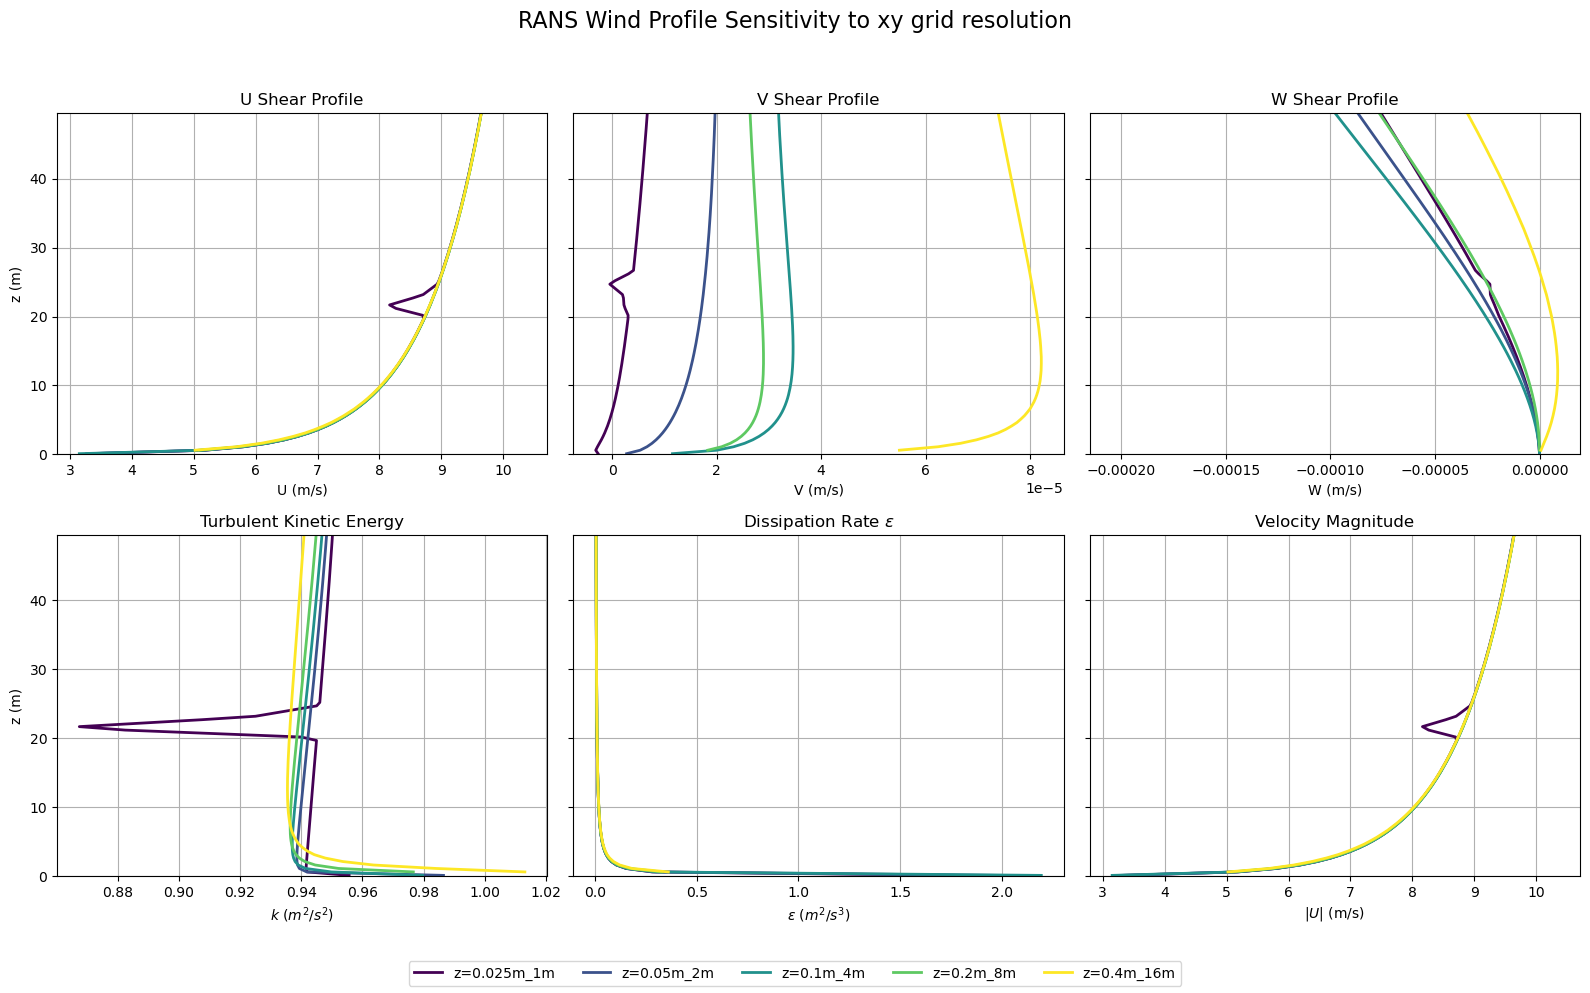

In [11]:
ylowlim = 0
yhighlim = 49.5

# RANS WIND PROFILE COMPARISON 
z_names_prop = ['z=0.025m_1m','z=0.05m_2m','z=0.1m_4m','z=0.2m_8m','z=0.4m_16m']
xy_names_prop = ['xy=1m','xy=2m','xy=4m','xy=8m','xy=16m']
case_names = z_names_prop
wfs = {}

for name in case_names:
    wfs[name] = WindField(profile='rans', ds=files[name])

z_vals = np.linspace(0.1, 100, 200)

profiles = {}

for name, wf in wfs.items():

    u = np.zeros(len(z_vals))
    v = np.zeros(len(z_vals))
    w = np.zeros(len(z_vals))
    k = np.zeros(len(z_vals))
    eps = np.zeros(len(z_vals))

    for i, z in enumerate(z_vals):

        vel, k[i], eps[i] = wf.get_profile_at(x=100,y=100,z=z)
        u[i], v[i], w[i] = vel

    profiles[name] = {
        'u': u,
        'v': v,
        'w': w,
        'k': k,
        'eps': eps,
        'Umag': np.sqrt(u**2 + v**2 + w**2)
    }

fig, axs = plt.subplots(2, 3,figsize=(16, 10),sharey=True)
colors = plt.cm.viridis(np.linspace(0, 1, len(case_names)))

for i, name in enumerate(case_names):
    p = profiles[name]
    # U
    axs[0,0].plot(p['u'],z_vals,linewidth=2,color=colors[i],label=name)
    # V
    axs[0,1].plot(p['v'],z_vals,linewidth=2,color=colors[i])
    # W
    axs[0,2].plot(p['w'],z_vals,linewidth=2,color=colors[i])
    # TKE
    axs[1,0].plot(p['k'],z_vals,linewidth=2,color=colors[i])
    # epsilon
    axs[1,1].plot(p['eps'],z_vals,linewidth=2,color=colors[i])
    # Velocity magnitude
    axs[1,2].plot(p['Umag'],z_vals,linewidth=2,color=colors[i])

axs[0,0].set_xlabel('U (m/s)')
axs[0,0].set_ylabel('z (m)')
axs[0,0].set_title('U Shear Profile')
axs[0,0].grid(True)
axs[0,0].set_ylim(ylowlim,yhighlim)
axs[0,1].set_xlabel('V (m/s)')
axs[0,1].set_title('V Shear Profile')
axs[0,1].grid(True)
axs[0,1].set_ylim(ylowlim,yhighlim)
axs[0,2].set_xlabel('W (m/s)')
axs[0,2].set_title('W Shear Profile')
axs[0,2].grid(True)
axs[0,2].set_ylim(ylowlim,yhighlim)
axs[1,0].set_xlabel(r'$k$ ($m^2/s^2$)')
axs[1,0].set_ylabel('z (m)')
axs[1,0].set_title('Turbulent Kinetic Energy')
axs[1,0].grid(True)
axs[1,0].set_ylim(ylowlim,yhighlim)
axs[1,1].set_xlabel(r'$\varepsilon$ ($m^2/s^3$)')
axs[1,1].set_title(r'Dissipation Rate $\varepsilon$')
axs[1,1].grid(True)
axs[1,1].set_ylim(ylowlim,yhighlim)
axs[1,2].set_xlabel(r'$|U|$ (m/s)')
axs[1,2].set_title('Velocity Magnitude')
axs[1,2].grid(True)
axs[1,2].set_ylim(ylowlim,yhighlim)

fig.legend(case_names,loc='lower center',ncol=len(case_names),fontsize=10,frameon=True)

fig.suptitle('RANS Wind Profile Sensitivity to xy grid resolution',fontsize=16)

plt.tight_layout(rect=[0,0.05,1,0.95])
plt.show()

## Looking if the error is club dependent

In [12]:
pga_data = [
    ["Driver", 115, -0.9, 171, 1.49, 10.4, 2545, 32, 39, 258],
    ["3-wood", 110, -2.3, 162, 1.47, 9.3, 3663, 29, 44, 228],
    ["5-wood", 106, -2.5, 156, 1.47, 9.7, 4322, 30, 48, 216],
    ["Hybrid", 102, -2.4, 149, 1.47, 10.2, 4587, 28, 49, 211],
    ["3 Iron", 100, -2.5, 145, 1.46, 10.3, 4404, 27, 48, 199],
    ["4 Iron", 98, -2.9, 140, 1.44, 10.8, 4782, 28, 49, 192],
    ["5 Iron", 96, -3.4, 135, 1.41, 11.9, 5280, 30, 50, 182],
    ["6 Iron", 94, -3.7, 130, 1.39, 14.0, 6204, 29, 50, 172],
    ["7 Iron", 92, -3.9, 123, 1.34, 16.1, 7124, 31, 51, 161],
    ["8 Iron", 89, -4.2, 118, 1.33, 17.8, 8078, 30, 51, 150],
    ["9 Iron", 87, -4.3, 112, 1.29, 20.0, 8793, 29, 52, 139],
    ["PW", 84, -4.7, 104, 1.24, 23.7, 9316, 29, 52, 130],
]

lpga_data = [
    ["Driver", 96, 2.8, 143, 1.49, 12.6, 2506, 24, 36, 204],
    ["3-wood", 92, -0.8, 135, 1.47, 11.6, 2595, 23, 38, 183],
    ["5-wood", 90, -1.6, 130, 1.46, 12.3, 4320, 23, 43, 173],
    ["Hybrid", 87, -1.9, 125, 1.44, 13.9, 4504, 23, 45, 163],
    ["4 Iron", 82, -1.7, 118, 1.43, 13.9, 4608, 23, 43, 160],
    ["5 Iron", 81, -2.0, 114, 1.42, 14.6, 4966, 23, 45, 152],
    ["6 Iron", 80, -2.3, 111, 1.41, 16.7, 5904, 23, 46, 142],
    ["7 Iron", 78, -2.5, 106, 1.38, 18.5, 6630, 24, 47, 131],
    ["8 Iron", 76, -2.8, 102, 1.36, 20.8, 7413, 25, 47, 122],
    ["9 Iron", 74, -3.2, 95, 1.30, 23.5, 7605, 25, 48, 112],
    ["PW", 72, -3.2, 88, 1.25, 25.2, 8465, 25, 48, 101],
]

columns = [
    "Club",
    "Club Speed (mph)",
    "Attack Angle (deg)",
    "Ball Speed (mph)",
    "Smash Factor",
    "Launch Angle (deg)",
    "Spin Rate (rpm)",
    "Max Height (m)",
    "Land Angle (deg)",
    "Carry (m)"
]

df_pga = pd.DataFrame(pga_data, columns=columns)
df_lpga = pd.DataFrame(lpga_data, columns=columns)


# convert from mph to m/s
df_pga['Ball Speed (mph)'] = df_pga['Ball Speed (mph)'] * 0.44704
df_pga = df_pga.rename(columns={'Ball Speed (mph)':'Ball Speed (m/s)'})
df_pga['Club Speed (mph)'] = df_pga['Club Speed (mph)'] * 0.44704
df_pga = df_pga.rename(columns={'Club Speed (mph)':'Club Speed (m/s)'})

df_lpga['Ball Speed (mph)'] = df_lpga['Ball Speed (mph)'] * 0.44704
df_lpga = df_lpga.rename(columns={'Ball Speed (mph)':'Ball Speed (m/s)'})
df_lpga['Club Speed (mph)'] = df_lpga['Club Speed (mph)'] * 0.44704
df_lpga = df_lpga.rename(columns={'Club Speed (mph)':'Club Speed (m/s)'})

df_pga

#items of interest
#df_pga['Ball Speed (m/s)'][i]
#df_pga['Launch Angle (deg)'][i]
#df_pga['Spin Rate (rpm)'][i]

,Club,Club Speed (m/s),Attack Angle (deg),Ball Speed (m/s),Smash Factor,Launch Angle (deg),Spin Rate (rpm),Max Height (m),Land Angle (deg),Carry (m)
0,Driver,51.40960,-0.9,76.44384,1.49,10.4,2545,32,39,258
1,3-wood,49.17440,-2.3,72.42048,1.47,9.3,3663,29,44,228
2,5-wood,47.38624,-2.5,69.73824,1.47,9.7,4322,30,48,216
3,Hybrid,45.59808,-2.4,66.60896,1.47,10.2,4587,28,49,211
4,3 Iron,44.70400,-2.5,64.82080,1.46,10.3,4404,27,48,199
5,4 Iron,43.80992,-2.9,62.58560,1.44,10.8,4782,28,49,192
6,5 Iron,42.91584,-3.4,60.35040,1.41,11.9,5280,30,50,182
7,6 Iron,42.02176,-3.7,58.11520,1.39,14.0,6204,29,50,172
8,7 Iron,41.12768,-3.9,54.98592,1.34,16.1,7124,31,51,161
9,8 Iron,39.78656,-4.2,52.75072,1.33,17.8,8078,30,51,150


In [13]:
def solve_trajectories_for_shot(files, ball_speed, launch_angle, spin_rate):

    trajectories = {}

    for key, file in files.items():

        wind = WindField(profile='rans', ds=file)

        traj = Trajectory(
            ball_speed=ball_speed,
            launch_angle=launch_angle,
            spin_rate=spin_rate,
            spin_axis=0,
            wind=wind
        )

        traj.solve(solver='euler', dt=0.01)

        trajectories[key] = traj

    return trajectories

In [14]:
all_results = []

for idx, row in df_pga.iterrows():

    club = row['Club']

    ball_speed = row['Ball Speed (m/s)']
    launch_angle = row['Launch Angle (deg)']
    spin_rate = row['Spin Rate (rpm)']

    print(f'Running {club}...')

    trajectories = solve_trajectories_for_shot(
        files,
        ball_speed,
        launch_angle,
        spin_rate
    )

    # ----------------------------------------
    # XY grid comparison
    # ----------------------------------------

    ref_xy = trajectories['xy=1m'].p

    for key in xy_keys:

        p = trajectories[key].p

        dx = x_distance_error(ref_xy, p)
        dy = y_distance_error(ref_xy, p)

        all_results.append({
            'Tour': 'PGA',
            'Club': club,
            'Grid Type': 'XY',
            'Grid': key,
            'dx': dx,
            'dy': dy
        })

    # ----------------------------------------
    # Z grid comparison
    # ----------------------------------------

    ref_z = trajectories['z=0.025m_1m'].p

    for key in z_keys:

        p = trajectories[key].p

        dx = x_distance_error(ref_z, p)
        dy = y_distance_error(ref_z, p)

        all_results.append({
            'Tour': 'PGA',
            'Club': club,
            'Grid Type': 'Z',
            'Grid': key,
            'dx': dx,
            'dy': dy
        })

Running Driver...
Running 3-wood...
Running 5-wood...
Running Hybrid...
Running 3 Iron...
Running 4 Iron...
Running 5 Iron...
Running 6 Iron...
Running 7 Iron...
Running 8 Iron...
Running 9 Iron...
Running PW...


In [15]:
df_results = pd.DataFrame(all_results)
display(df_results)

,Tour,Club,Grid Type,Grid,dx,dy
0,PGA,Driver,XY,xy=1m,0.000000,0.000000
1,PGA,Driver,XY,xy=2m,0.008370,-0.000012
2,PGA,Driver,XY,xy=4m,0.008425,0.000005
3,PGA,Driver,XY,xy=8m,0.007715,0.000007
4,PGA,Driver,XY,xy=16m,0.007897,0.000004
...,...,...,...,...,...,...
115,PGA,PW,Z,z=0.025m_1m,0.000000,0.000000
116,PGA,PW,Z,z=0.05m_2m,0.221597,0.000017
117,PGA,PW,Z,z=0.1m_4m,0.222504,0.000025
118,PGA,PW,Z,z=0.2m_8m,0.202993,0.000017


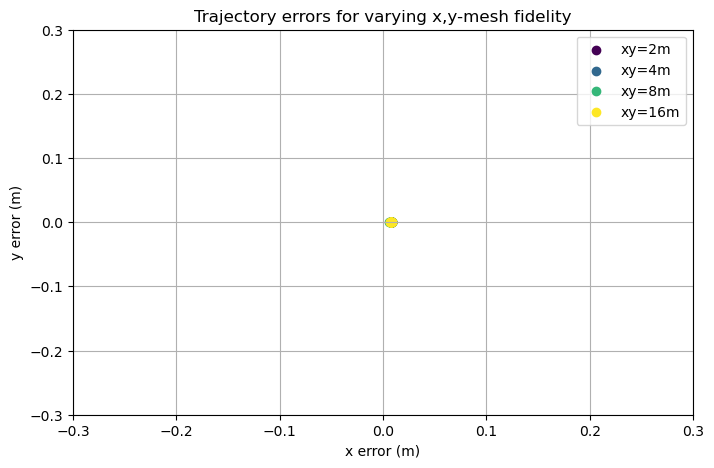

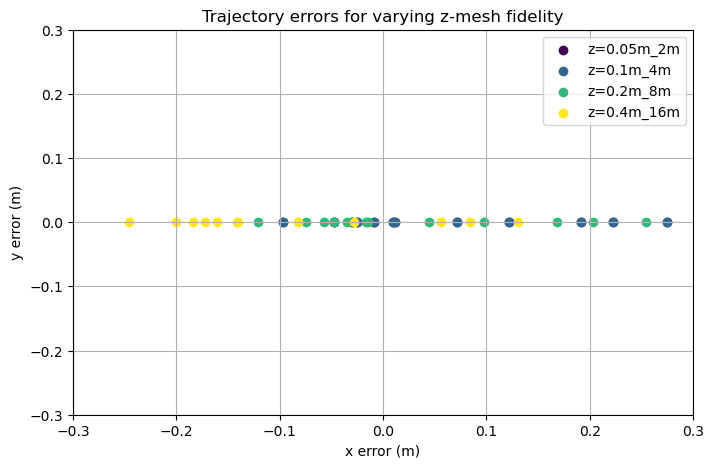

In [21]:
xy2m = df_results[(df_results['Grid']== xy_keys[1])]     
xy4m = df_results[(df_results['Grid']== xy_keys[2])]
xy8m = df_results[(df_results['Grid']== xy_keys[3])]
xy16m = df_results[(df_results['Grid']== xy_keys[4])]
z005m2m = df_results[(df_results['Grid']== z_keys[1])]
z005m2m = df_results[(df_results['Grid']== z_keys[2])]
z02m8m = df_results[(df_results['Grid']== z_keys[3])]
z04m16m = df_results[(df_results['Grid']== z_keys[4])]

plt.figure(figsize=(8,5))
colors_a = plt.cm.viridis(np.linspace(0, 1, 4))
plt.scatter(xy2m['dx'],xy2m['dy'],marker='o',color=colors_a[0],label=xy_keys[1])
plt.scatter(xy4m['dx'],xy4m['dy'],marker='o',color=colors_a[1],label=xy_keys[2])
plt.scatter(xy8m['dx'],xy8m['dy'],marker='o',color=colors_a[2],label=xy_keys[3])
plt.scatter(xy16m['dx'],xy16m['dy'],marker='o',color=colors_a[3],label=xy_keys[4])
plt.grid(True)
plt.xlabel('x error (m)')
plt.ylabel('y error (m)')
plt.xlim(-0.3,0.3)
plt.ylim(-0.3,0.3)
plt.title('Trajectory errors for varying x,y-mesh fidelity')
plt.legend()
plt.show()

plt.figure(figsize=(8,5))
colors_a = plt.cm.viridis(np.linspace(0, 1, 4))
plt.scatter(z005m2m['dx'],z005m2m['dy'],marker='o',color=colors_a[0],label=z_keys[1])
plt.scatter(z005m2m['dx'],z005m2m['dy'],marker='o',color=colors_a[1],label=z_keys[2])
plt.scatter(z02m8m['dx'],z02m8m['dy'],marker='o',color=colors_a[2],label=z_keys[3])
plt.scatter(z04m16m['dx'],z04m16m['dy'],marker='o',color=colors_a[3],label=z_keys[4])
plt.grid(True)
plt.xlabel('x error (m)')
plt.ylabel('y error (m)')
plt.xlim(-0.3,0.3)
plt.ylim(-0.3,0.3)
plt.title('Trajectory errors for varying z-mesh fidelity')
plt.legend()
plt.show()

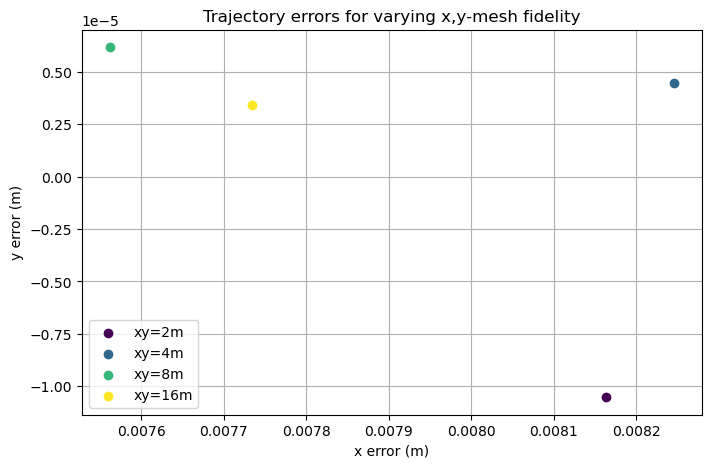

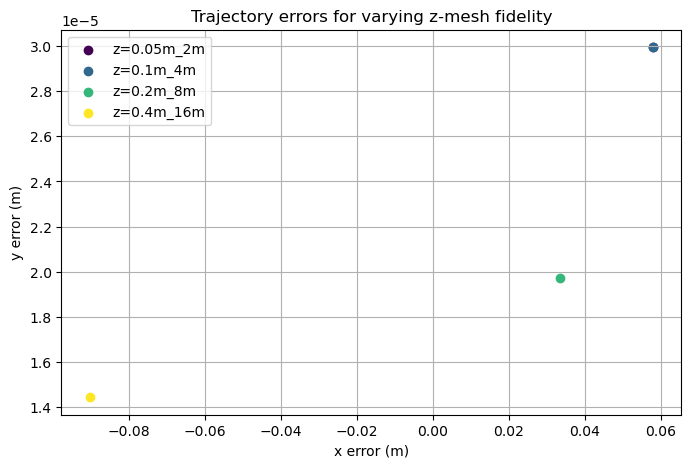

In [23]:
plt.figure(figsize=(8,5))
colors_a = plt.cm.viridis(np.linspace(0, 1, 4))
plt.scatter(xy2m['dx'].mean(),xy2m['dy'].mean(),marker='o',color=colors_a[0],label=xy_keys[1])
plt.scatter(xy4m['dx'].mean(),xy4m['dy'].mean(),marker='o',color=colors_a[1],label=xy_keys[2])
plt.scatter(xy8m['dx'].mean(),xy8m['dy'].mean(),marker='o',color=colors_a[2],label=xy_keys[3])
plt.scatter(xy16m['dx'].mean(),xy16m['dy'].mean(),marker='o',color=colors_a[3],label=xy_keys[4])
plt.grid(True)
plt.xlabel('x error (m)')
plt.ylabel('y error (m)')
plt.title('Trajectory errors for varying x,y-mesh fidelity')
plt.legend()
plt.show()

plt.figure(figsize=(8,5))
colors_a = plt.cm.viridis(np.linspace(0, 1, 4))
plt.scatter(z005m2m['dx'].mean(),z005m2m['dy'].mean(),marker='o',color=colors_a[0],label=z_keys[1])
plt.scatter(z005m2m['dx'].mean(),z005m2m['dy'].mean(),marker='o',color=colors_a[1],label=z_keys[2])
plt.scatter(z02m8m['dx'].mean(),z02m8m['dy'].mean(),marker='o',color=colors_a[2],label=z_keys[3])
plt.scatter(z04m16m['dx'].mean(),z04m16m['dy'].mean(),marker='o',color=colors_a[3],label=z_keys[4])
plt.grid(True)
plt.xlabel('x error (m)')
plt.ylabel('y error (m)')
plt.title('Trajectory errors for varying z-mesh fidelity')
plt.legend()
plt.show()